# Column Cleaning - Discipline Results
This notebook focuses on cleaning and standardizing columns in the discipline_results_ingest table

In [1]:
import sys
sys.path.append('../../')

# Import and reload to pick up latest changes
import importlib
from database import Database
import src.analysis.player_features
importlib.reload(src.analysis.player_features)
from src.analysis import individual_performance_analysis, event_specific_analysis, comparative_analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Connect to Database and Load Data

In [2]:
# Connect to database
db = Database(file='../../swim_database_2.sqlite3')
print("Database connection established")

Database connection established


In [3]:
# Load discipline_results_ingest table
df = pd.read_sql_query('SELECT * FROM discipline_results_ingest', db.conn)
print(f"Loaded {len(df):,} records from discipline_results_ingest")
print(f"Shape: {df.shape}")
df.head()

Loaded 127,841 records from discipline_results_ingest
Shape: (127841, 31)


,level_0,level_0_production,index,competition_name,competition_link,competition_tabindex,discipline_link,Event number,Event,Category,Minimum,Start Time,Total Entries,Total Participants,results_link,competition_link_check,results_link_check,TotalParticipantsInt,Date,Year,Time,Status,Place,Full name,Year Of Birth,\r\n Club\r\n,Heat,Lane,Results,Points,table_first_row
0,0,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,1,SHIRA BEN-YAISH,2009,Hapoel Emek Yizrael,2,4,00:36.37,334,Direct Finals
1,1,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,2,VIEL MILSHTEIN,2011,Hapoel Emek Yizrael,2,3,00:39.95,252,Direct Finals
2,2,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,3,Mariya Chechotkin,2009,Hapoel Emek Yizrael,2,7,00:41.47,225,Direct Finals
3,3,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,4,SELEN SWAN,2013,Hapoel Lev Hagalil Saknin,1,3,00:47.13,153,Direct Finals
4,4,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,5,LIDA ZELIKMAN,2013,Olimp Swimming Club,1,5,00:48.59,140,Direct Finals


## 2. Quick Data Overview

In [4]:
# Check column names and types
print("Columns in the dataset:")
print(df.dtypes)
print(f"\nTotal columns: {len(df.columns)}")

Columns in the dataset:
level_0                                      int64
level_0_production                           int64
index                                        int64
competition_name                            object
competition_link                            object
competition_tabindex                        object
discipline_link                             object
Event number                                object
Event                                       object
Category                                    object
Minimum                                     object
Start Time                                  object
Total Entries                               object
Total Participants                          object
results_link                                object
competition_link_check                       int64
results_link_check                           int64
TotalParticipantsInt                         int64
Date                                        object
Year   

In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print("Missing Values Summary:")
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

Missing Values Summary:


,Missing Count,Percentage
Year Of Birth,5269,4.121526


## 3. Convert Results Column to Seconds

In [6]:
# Import the conversion function
from functions import parse_swim_time_to_seconds

# Apply conversion to Results column
df['result_seconds'] = df['Results'].apply(parse_swim_time_to_seconds)

# Show conversion results
print("Sample conversions:")
sample = df[['Results', 'result_seconds']].head(20)
print(sample)
print(f"\nSuccessfully converted: {df['result_seconds'].notna().sum():,} records")
print(f"Failed conversions: {df['result_seconds'].isna().sum():,} records")
print(f"Conversion rate: {df['result_seconds'].notna().sum() / len(df) * 100:.2f}%")

Sample conversions:
     Results  result_seconds
0   00:36.37           36.37
1   00:39.95           39.95
2   00:41.47           41.47
3   00:47.13           47.13
4   00:48.59           48.59
5   00:51.33           51.33
6   00:52.60           52.60
7   00:54.66           54.66
8   00:55.40           55.40
9   00:55.72           55.72
10  00:57.53           57.53
11  01:12.30           72.30
12       DNS             NaN
13       DNS             NaN
14       DNS             NaN
15  00:28.01           28.01
16  00:33.14           33.14
17  00:34.90           34.90
18  00:38.36           38.36
19  00:39.38           39.38

Successfully converted: 113,654 records
Failed conversions: 14,187 records
Conversion rate: 88.90%


In [7]:
# Check for any failed conversions
failed_conversions = df[df['result_seconds'].isna() & df['Results'].notna()]
if len(failed_conversions) > 0:
    print(f"Failed conversions ({len(failed_conversions)} records):")
    print(failed_conversions[['Results', 'result_seconds']].head(10))
else:
    print("All non-null Results were successfully converted!")

Failed conversions (14187 records):
   Results  result_seconds
12     DNS             NaN
13     DNS             NaN
14     DNS             NaN
41     DNF             NaN
42     DNS             NaN
43     DNS             NaN
58     DNS             NaN
59     DNS             NaN
88     DNS             NaN
89     DNS             NaN


Result Times Statistics (in seconds):
count    113654.000000
mean        117.598205
std         114.729774
min           0.000000
25%          54.500000
50%          85.310000
75%         149.160000
max        1536.900000
Name: result_seconds, dtype: float64


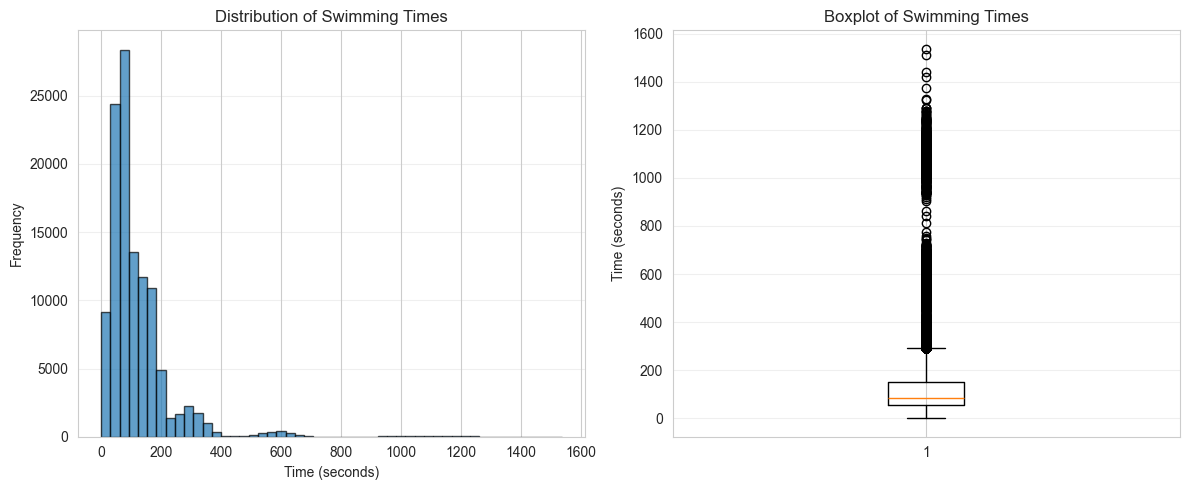

In [8]:
# Basic statistics on result_seconds
print("Result Times Statistics (in seconds):")
print(df['result_seconds'].describe())

# Visualize distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['result_seconds'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Swimming Times')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['result_seconds'].dropna(), vert=True)
plt.ylabel('Time (seconds)')
plt.title('Boxplot of Swimming Times')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Event-Specific Analysis: 200m Backstroke All Girls Categories

In [9]:
# Check available values for Event and Category columns
print("Unique Events (sample):")
print(df['Event'].value_counts().head(20))
print("\n" + "="*50)
print("\nUnique Categories (sample):")
print(df['Category'].value_counts().head(20))

Unique Events (sample):
Event
50m Freestyle             17953
100m Freestyle            16501
100m Backstroke           11431
100m Breaststroke          9542
200m Freestyle             8059
200m Individual Medley     7077
50m Butterfly              7008
100m Butterfly             6857
100m Individual Medley     6417
50m Breaststroke           5670
200m Backstroke            5462
400m Freestyle             4946
50m Backstroke             4249
200m Breaststroke          4117
200m Butterfly             2711
400m Individual Medley     2238
4X50m Medley Relay         2081
4X50m Freestyle Relay      1901
800m Freestyle             1626
1500m Freestyle             593
Name: count, dtype: int64


Unique Categories (sample):
Category
Men 14-99      12878
Women 13-99     9821
Boys 10-14      8784
                7933
Men 15-99       5569
Women 14-99     5368
Boys 14         4901
Boys 12         4723
Boys 13         4689
Girls 10-13     4685
Girls 13        3971
Girls 12        3553
Men 10-99    

In [10]:
# Show ALL unique categories with their counts
print("All Available Categories:")
print("=" * 60)
categories = df['Category'].value_counts().sort_index()
for category, count in categories.items():
    print(f"{category}: {count:,} records")
    
print(f"\nTotal unique categories: {df['Category'].nunique()}")
print(f"Total records: {len(df):,}")

All Available Categories:
: 7,933 records
10-14 Mix: 22 records
Boys 10: 2,233 records
Boys 10-11: 1,149 records
Boys 10-12: 638 records
Boys 10-14: 8,784 records
Boys 10-18: 763 records
Boys 10-20: 52 records
Boys 11: 2,558 records
Boys 11-12: 200 records
Boys 11-18: 121 records
Boys 12: 4,723 records
Boys 12-14: 451 records
Boys 12-15: 879 records
Boys 12-17: 180 records
Boys 12-18: 216 records
Boys 13: 4,689 records
Boys 13-14: 1,080 records
Boys 13-15: 19 records
Boys 13-18: 10 records
Boys 14: 4,901 records
Boys 15-16: 1,842 records
Boys 8-11: 96 records
Boys 8-14: 365 records
Boys 8-9: 29 records
Boys 8-99: 1,183 records
Boys 9: 194 records
Boys 9-11: 186 records
Boys 9-12: 24 records
Boys 9-14: 918 records
Boys 9-19: 648 records
Boys10-19: 619 records
Girls 10: 1,634 records
Girls 10-11: 1,226 records
Girls 10-12: 34 records
Girls 10-13: 4,685 records
Girls 10-14: 832 records
Girls 10-15: 211 records
Girls 10-18: 601 records
Girls 10-19: 402 records
Girls 10-20: 91 records
Girls

In [11]:
# Test: Check what categories exist for 200m Backstroke
backstroke_200_df = df[df['Event'].str.contains('200.*Backstroke', case=False, na=False)]
print(f"Total 200m Backstroke records: {len(backstroke_200_df)}")
print(f"\nCategories for 200m Backstroke:")
print(backstroke_200_df['Category'].value_counts().head(20))

Total 200m Backstroke records: 5462

Categories for 200m Backstroke:
Category
Men 14-99      584
Women 13-99    433
Boys 13        360
Boys 10-14     353
Boys 14        346
Boys 12        339
               311
Girls 13       270
Girls 12       262
Women 14-99    220
Men 15-99      177
Boys 11        168
Girls 10-13    152
Girls 11       138
Girls 14        68
Men 10-99       66
Boys 15-16      63
Boys 8-99       60
Men 13-99       60
Boys 12-15      60
Name: count, dtype: int64



200.*Backstroke Distribution Summary:
  Total results: 738
  Categories: ['Girls 11', 'Girls 12', 'Girls 13', 'Girls 14']

Statistics by Category:
          count    mean  median     min     max
Category                                       
Girls 11    134  205.15  204.85  170.70  259.82
Girls 12    246  182.18  181.70  152.68  204.78
Girls 13    263  170.83  170.76  146.09  202.78
Girls 14     62  159.66  160.92  136.92  171.68


c:\Repository\SwinLaLigScrap\notebooks\01_eda\../..\src\analysis\player_features.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=event_data, x='Category', y='result_seconds',


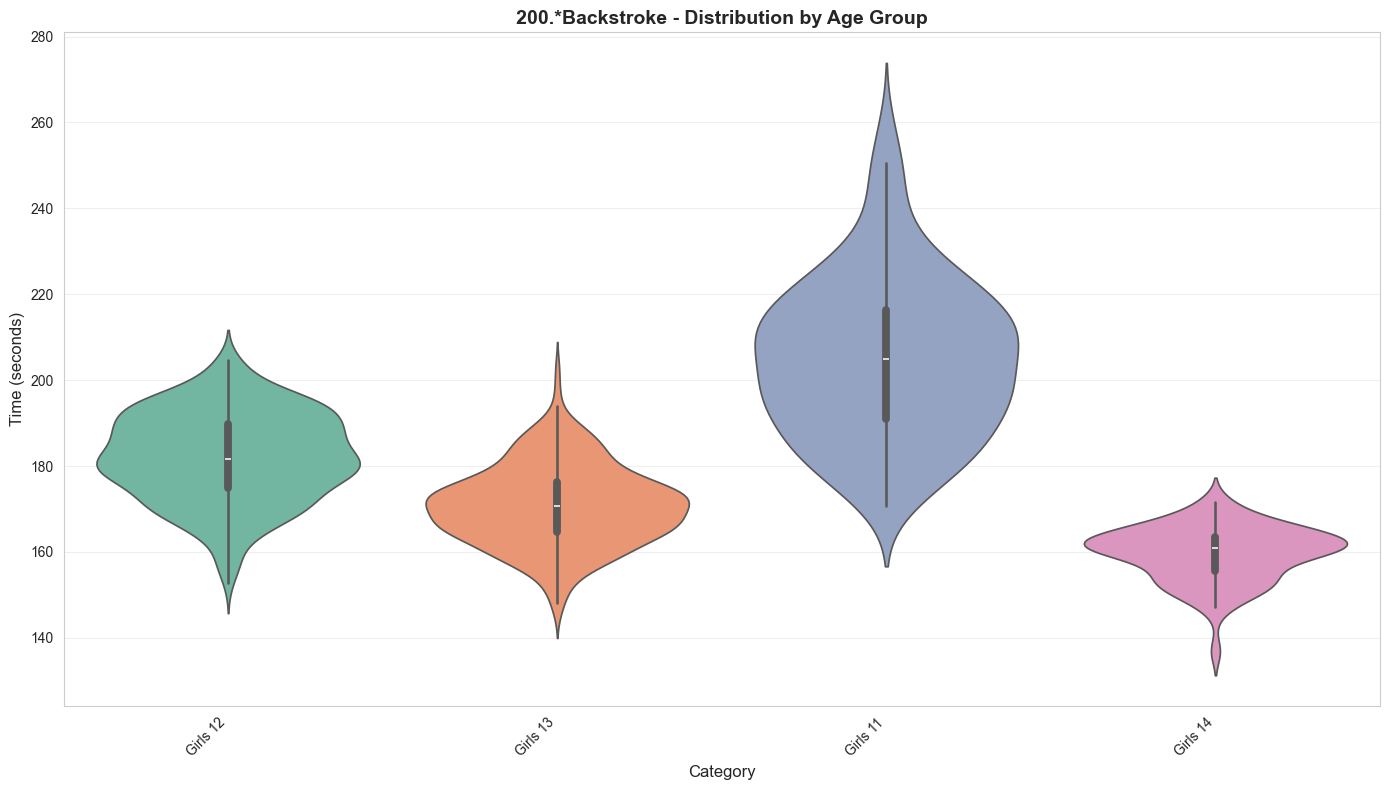

In [12]:
# Use modular function for event-specific analysis
# Using actual categories that exist in the database
event_200back_girls = event_specific_analysis(
    df,
    '200.*Backstroke',
    categories=['Girls 11', 'Girls 12', 'Girls 13', 'Girls 14']
)

In [13]:
# Visualization and statistics are automatically generated by the function above

## 5. Individual Performance Analysis: Ayala Saloma - 100m Backstroke


Ayala Saloma - 100.*Backstroke Performance Summary:
  Total races: 11
  First recorded time: 103.57s
  Best time: 93.22s
  Latest time: 94.47s
  Improvement from first: 10.35s (10.0%)


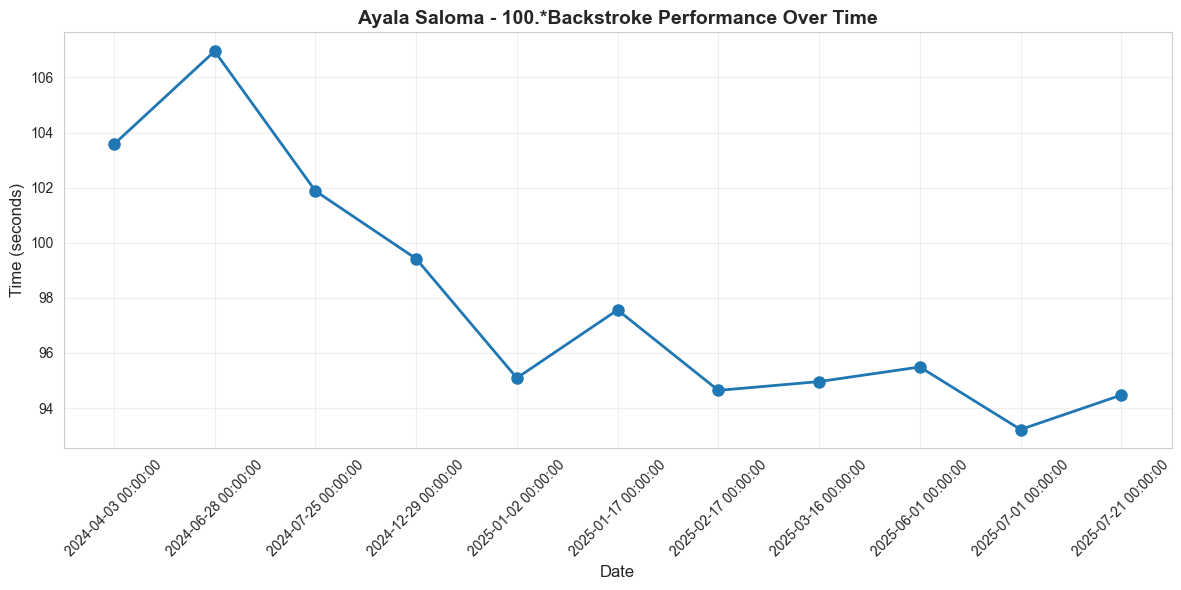

In [14]:
# Use modular function for individual performance analysis
ayala_100m_back = individual_performance_analysis(df, 'Ayala Saloma', '100.*Backstroke')

In [15]:
# Test: Check what events AYALA SALOMA has
ayala_data = df[df['Full name'] == 'AYALA SALOMA']
print(f"Total records for AYALA SALOMA: {len(ayala_data)}")
print(f"\nEvents for AYALA SALOMA:")
print(ayala_data['Event'].value_counts())

# Check for 100m Backstroke specifically
backstroke_100 = ayala_data[ayala_data['Event'].str.contains('100.*Backstroke', case=False, na=False)]
print(f"\n100m Backstroke records: {len(backstroke_100)}")

Total records for AYALA SALOMA: 49

Events for AYALA SALOMA:
Event
100m Backstroke           11
200m Backstroke            7
50m Butterfly              5
100m Breaststroke          5
100m Freestyle             4
50m Freestyle              4
100m Individual Medley     4
50m Breaststroke           3
200m Individual Medley     2
200m Freestyle             1
100m Butterfly             1
50m Backstroke             1
400m Freestyle             1
Name: count, dtype: int64

100m Backstroke records: 11


In [16]:
# Reload the module to pick up the changes
import importlib
import src.analysis.player_features
importlib.reload(src.analysis.player_features)
from src.analysis import individual_performance_analysis, event_specific_analysis, comparative_analysis
print("Module reloaded successfully")

Module reloaded successfully


In [17]:
# Check the actual function source code
import inspect
source = inspect.getsource(individual_performance_analysis)
# Print just the filter part
lines = source.split('\n')
for i, line in enumerate(lines[0:20]):
    print(f"{i}: {line}")

0: def individual_performance_analysis(
1:     df: pd.DataFrame,
2:     full_name: str,
3:     event_pattern: str,
4:     title: Optional[str] = None
5: ) -> pd.DataFrame:
6:     """
7:     Analyze an individual swimmer's performance over time for a specific event.
8:     
9:     This function creates a visualization showing performance progression over time
10:     and calculates improvement statistics.
11:     
12:     Parameters
13:     ----------
14:     df : pd.DataFrame
15:         DataFrame containing swimming results with columns:
16:         - 'Full name': Swimmer's full name
17:         - 'Event name': Event description
18:         - 'Date': Competition date
19:         - 'result_seconds': Time in seconds


In [18]:
# Visualization is automatically generated by the function above
    print(f"  Improvement: {improvement:.2f}s ({improvement_pct:.2f}%)")

IndentationError: unexpected indent (1049438618.py, line 2)

## 5a. Comparative Analysis: Ayala Saloma vs. Same Birth Year - 100m Backstroke

## 6. Individual Performance Analysis: Amit Gur - 200m Freestyle


Amit Gur - 200.*Freestyle Performance Summary:
  Total races: 8
  First recorded time: 189.63s
  Best time: 152.03s
  Latest time: 152.03s
  Improvement from first: 37.60s (19.8%)


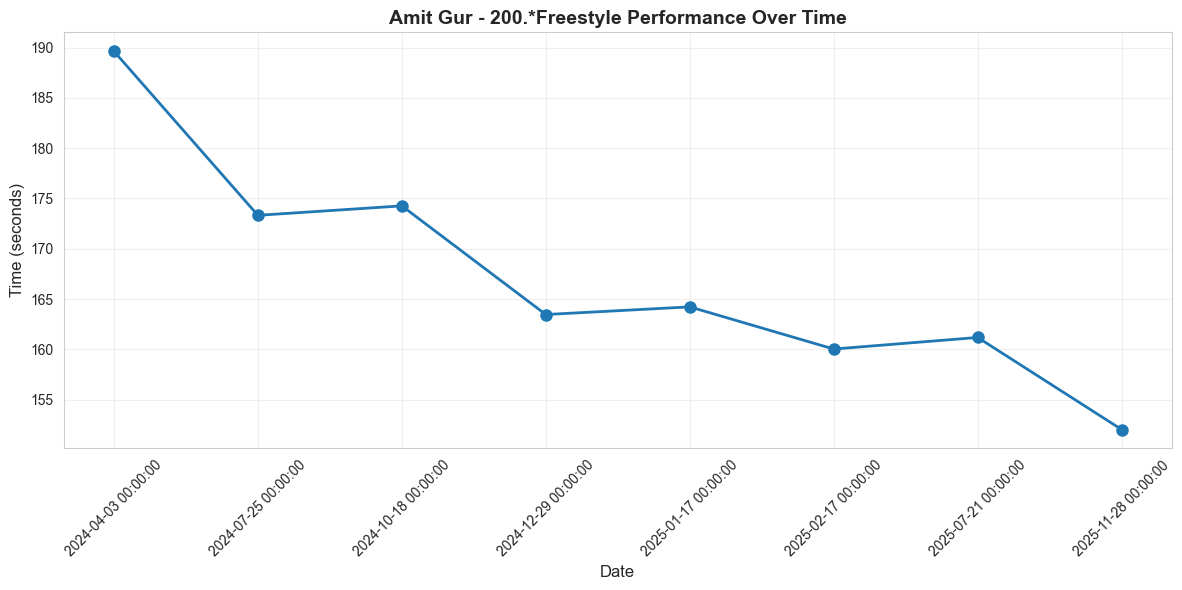

In [ ]:
# Use modular function for individual performance analysis
amit_200m_free = individual_performance_analysis(df, 'Amit Gur', '200.*Freestyle')

In [ ]:
# Visualization is automatically generated by the function above
print(f"  Improvement: {improvement:.2f}s ({improvement_pct:.2f}%)")

NameError: name 'improvement' is not defined

## 7. Event-Specific Analysis: 200m Freestyle All Boys Categories


200.*Freestyle Distribution Summary:
  Total results: 53
  Categories: ['Boys 15-16']

Statistics by Category:
            count    mean  median   min     max
Category                                       
Boys 15-16     43  122.83  126.70  0.00  133.29


c:\Repository\SwinLaLigScrap\notebooks\01_eda\../..\src\analysis\player_features.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=event_data, x='Category', y='result_seconds',


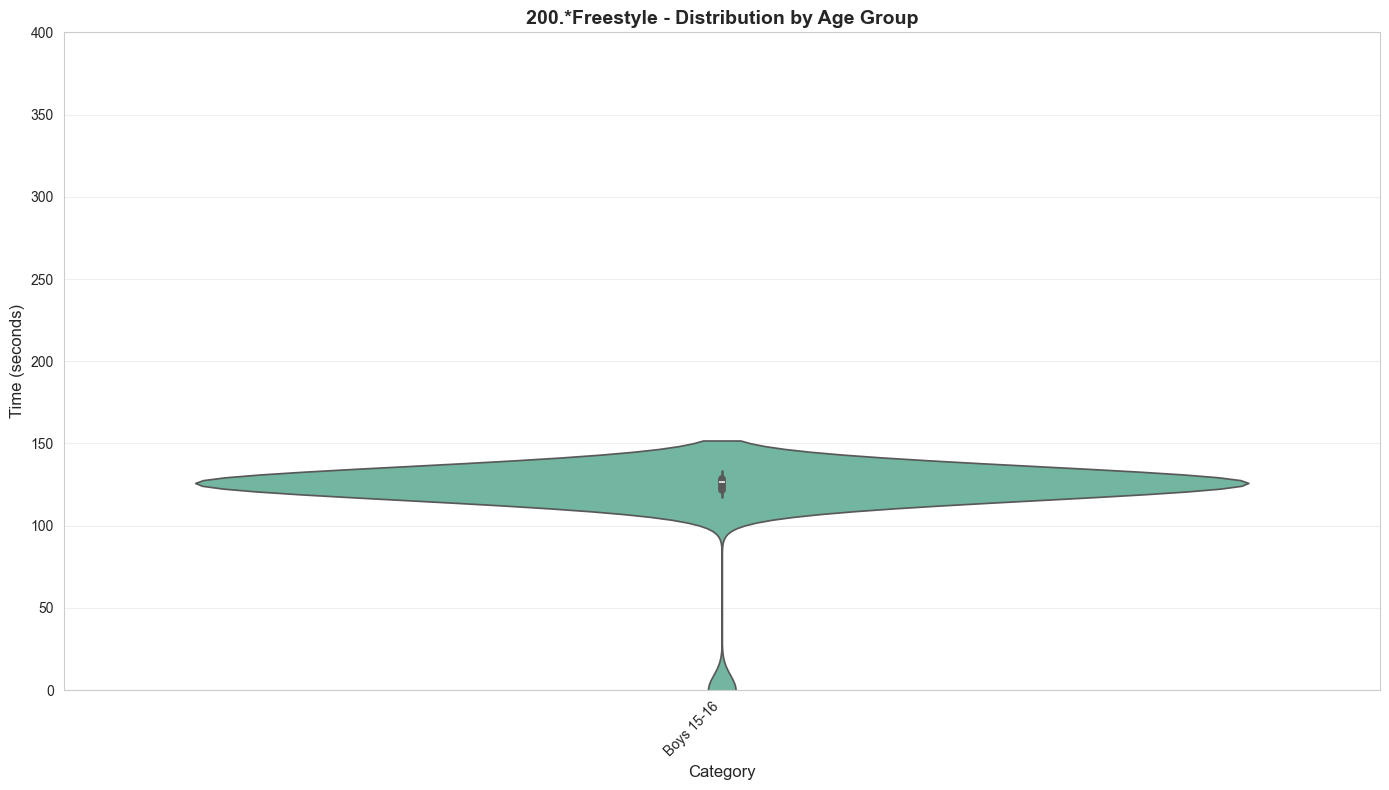

In [ ]:
# Use modular function for event-specific analysis
event_200free_boys = event_specific_analysis(
    df,
    '200.*Freestyle',
    categories=['Boys 11-12', 'Boys 13-14', 'Boys 15-16', 'Boys 17-18'],
    ylim=(0, 400)
)

In [ ]:
# Visualization and statistics are automatically generated by the function above

## 8. Comparative Analysis: Amit Gur vs. Same Birth Year - 200m Freestyle


Amit Gur - 200.*Freestyle (Boys) Comparative Analysis:
  Swimmer's best time: 160.03s
  Cohort size: 1157 swimmers
  Cohort mean: 168.60s
  Cohort median: 162.81s
  Cohort std dev: 33.50s
  Percentile rank: nan%
  Faster swimmers: 499
  Slower swimmers: 570
  Performance: 8.57s faster than average


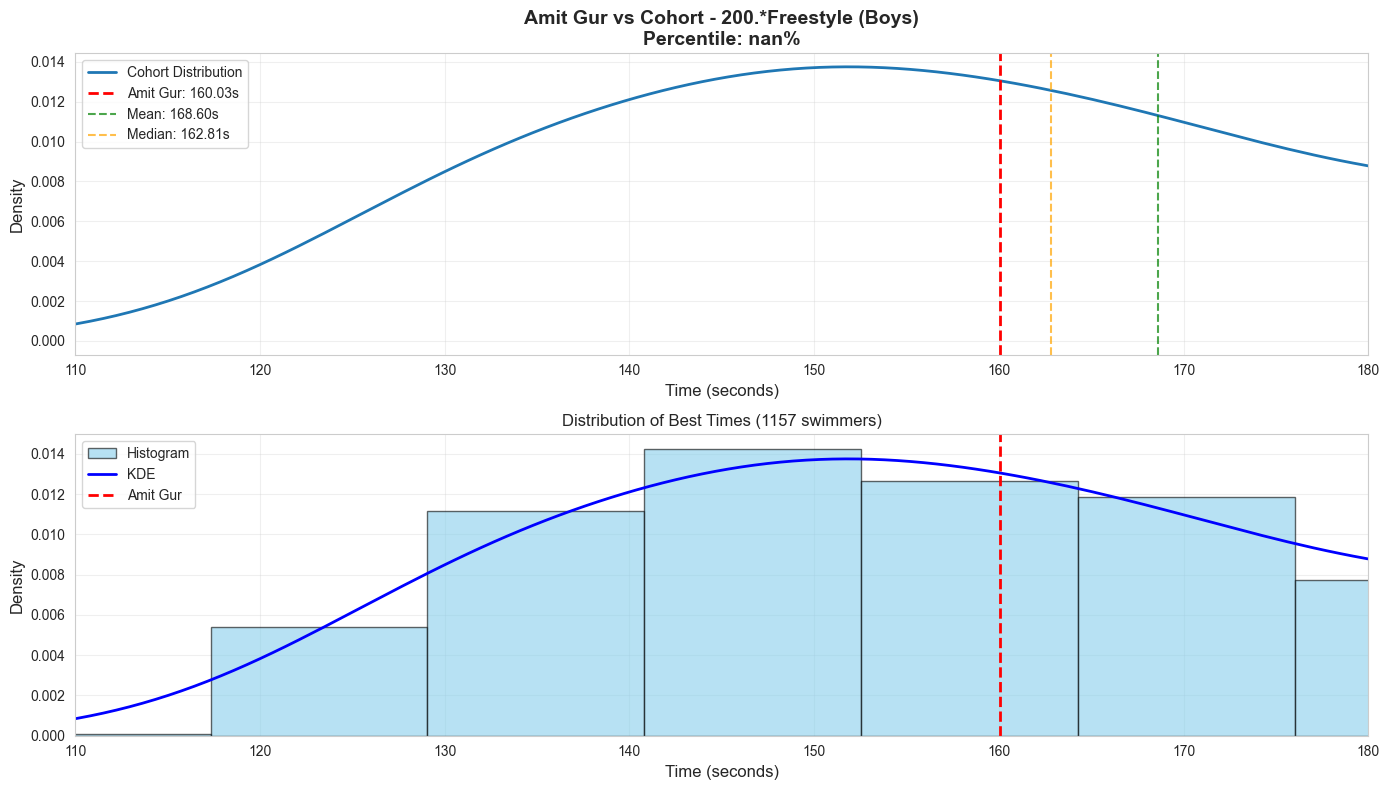

In [ ]:
# Use modular function for comparative analysis
cohort_amit_200free, swimmer_amit_200free = comparative_analysis(
    df, 
    'Amit Gur', 
    '200.*Freestyle', 
    'Boys',
    xlim=(110, 180)
)

In [ ]:
# Visualization and statistics are automatically generated by the function above

## 9. Individual Performance Analysis: Amit Gur - 100m Backstroke

In [ ]:
# Use modular function for individual performance analysis
amit_100m_back = individual_performance_analysis(df, 'Amit Gur', '100.*Backstroke')

In [ ]:
# Visualization is automatically generated by the function above

## 10. Event-Specific Analysis: 100m Backstroke All Boys Categories


100.*Backstroke Distribution Summary:
  Total results: 306
  Categories: ['Boys 11-12', 'Boys 13-14', 'Boys 15-16']

Statistics by Category:
            count   mean median    min    max
Category                                     
Boys 11-12     26  88.56  88.27  77.99  94.26
Boys 13-14    107  77.41  78.01  63.97  89.72
Boys 15-16    132  66.33  66.31  58.07  74.32


c:\Repository\SwinLaLigScrap\notebooks\01_eda\../..\src\analysis\player_features.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=event_data, x='Category', y='result_seconds',


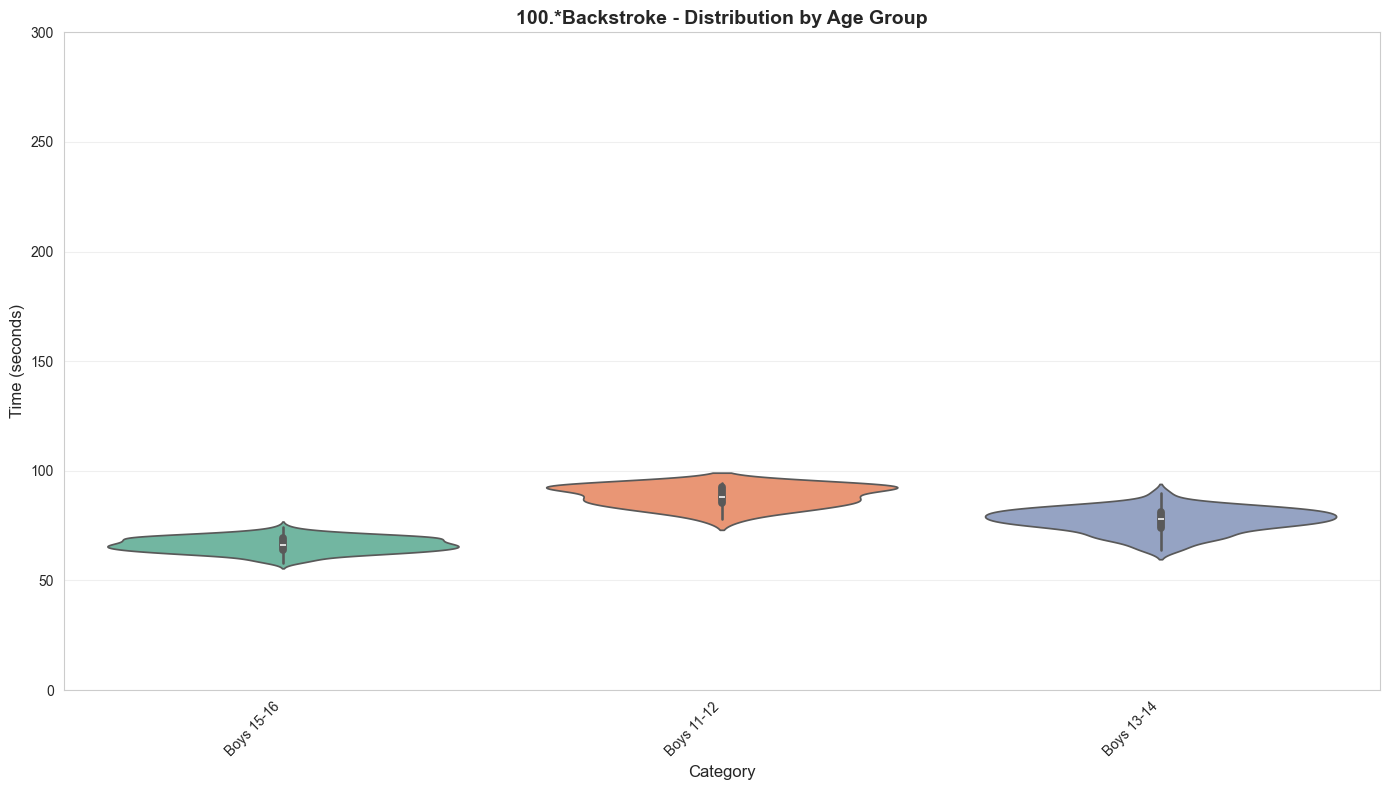

In [ ]:
# Use modular function for event-specific analysis
event_100back_boys = event_specific_analysis(
    df,
    '100.*Backstroke',
    categories=['Boys 11-12', 'Boys 13-14', 'Boys 15-16', 'Boys 17-18'],
    ylim=(0, 300)
)

In [ ]:
# Visualization and statistics are automatically generated by the function above

## 11. Comparative Analysis: Amit Gur vs. Same Birth Year - 100m Backstroke


Amit Gur - 100.*Backstroke (Boys) Comparative Analysis:
  Birth year: 2014
  Swimmer's best time: 80.23s
  Cohort size: 266 swimmers (same birth year)
  Cohort mean: 101.66s
  Cohort median: 100.72s
  Cohort std dev: 14.79s
  Percentile rank: nan%
  Faster swimmers: 6
  Slower swimmers: 245
  Performance: 21.43s faster than average


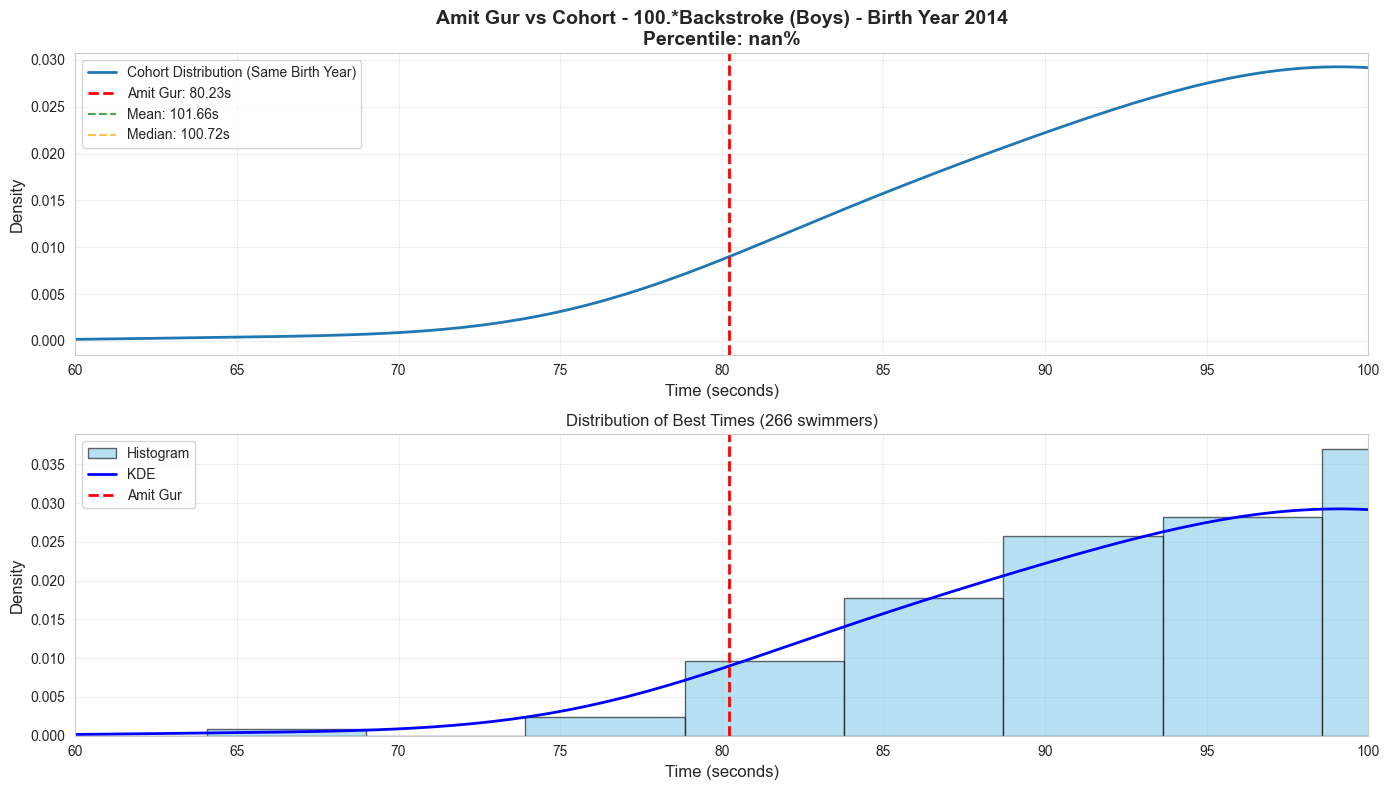

In [19]:
# Use modular function for comparative analysis
cohort_amit_100back, swimmer_amit_100back = comparative_analysis(
    df, 
    'Amit Gur', 
    '100.*Backstroke', 
    'Boys',
    xlim=(60, 100)
)

In [ ]:
# Create density plot with Amit's position highlighted
plt.figure(figsize=(14, 7))

# Plot density (KDE) of all results for same birth year (Boys only)
same_birth_year_backstroke_df['result_seconds'].plot(kind='density', linewidth=2.5, color='skyblue', label='All boys (same birth year - best times)')

# Fill under the curve for better visualization
from scipy import stats
density = stats.gaussian_kde(same_birth_year_backstroke_df['result_seconds'])
xs = np.linspace(0, 300, 500)
ys = density(xs)
plt.fill_between(xs, ys, alpha=0.3, color='skyblue')

# Overlay Amit's results
for result in amit_backstroke_results:
    plt.axvline(x=result, color='red', linestyle='--', linewidth=2.5, alpha=0.8)

# Add a single label for Amit's results
plt.axvline(x=amit_backstroke_results.iloc[0], color='red', linestyle='--', linewidth=2.5, alpha=0.8, label="Amit Gur's best time")

plt.title(f"100m Backstroke Performance Distribution - Birth Year {int(amit_birth_year_backstroke)} (Boys Only)\nAmit Gur's Position Among Peers (Best Times)", 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 300)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Calculate percentile rankings for Amit's results
print("\nAmit Gur's Performance Percentiles:")
for idx, result in enumerate(amit_backstroke_results):
    percentile = (same_birth_year_backstroke_df['result_seconds'] > result).sum() / len(same_birth_year_backstroke_df) * 100
    print(f"  Best time ({result:.2f}s): {percentile:.1f}th percentile (better than {percentile:.1f}% of swimmers)")

# Show how many swimmers are faster/slower than Amit's best time
amit_best_backstroke = amit_backstroke_results.min()
faster_swimmers = (same_birth_year_backstroke_df['result_seconds'] < amit_best_backstroke).sum()
slower_swimmers = (same_birth_year_backstroke_df['result_seconds'] > amit_best_backstroke).sum()
print(f"\nCompared to Amit's best time ({amit_best_backstroke:.2f}s):")
print(f"  Faster swimmers: {faster_swimmers} ({faster_swimmers/len(same_birth_year_backstroke_df)*100:.1f}%)")
print(f"  Slower swimmers: {slower_swimmers} ({slower_swimmers/len(same_birth_year_backstroke_df)*100:.1f}%)")

## 12. Individual Performance Analysis: Amit Gur - 200m Backstroke

In [ ]:
# Use modular function for individual performance analysis
amit_200m_back = individual_performance_analysis(df, 'Amit Gur', '200.*Backstroke')

In [ ]:
# Visualization is automatically generated by the function above
    print(f"  Latest time ({last_date}): {last_time:.2f}s")
    print(f"  Improvement: {improvement:.2f}s ({improvement_pct:.2f}%)")

## 13. Event-Specific Analysis: 200m Backstroke All Boys Categories

In [ ]:
# Use modular function for event-specific analysis
event_200back_boys = event_specific_analysis(
    df,
    '200.*Backstroke',
    categories=['Boys 11-12', 'Boys 13-14', 'Boys 15-16', 'Boys 17-18'],
    ylim=(0, 400)
)

In [ ]:
# Visualization and statistics are automatically generated by the function above

## 14. Comparative Analysis: Amit Gur vs. Same Birth Year - 200m Backstroke

In [ ]:
# Get Amit Gur's year of birth
amit_birth_year_200backstroke = df[df['Full name'].str.lower() == 'amit gur']['Year Of Birth'].iloc[0]
print(f"Amit Gur's Year of Birth: {amit_birth_year_200backstroke}")

# Filter for all swimmers with same birth year in 200m Backstroke - BOYS ONLY
same_birth_year_200backstroke_df = df[
    (df['Year Of Birth'] == amit_birth_year_200backstroke) &
    (df['Event'].str.contains('200.*Backstroke', case=False, na=False)) &
    #(df['Category'].str.contains('Boys', case=False, na=False)) &
    (df['result_seconds'].notna())
].copy()

# Group by Full name and take only the best (minimum) time for each swimmer
same_birth_year_200backstroke_df = same_birth_year_200backstroke_df.groupby('Full name', as_index=False)['result_seconds'].min()

# Get Amit's results specifically
amit_200backstroke_results = same_birth_year_200backstroke_df[same_birth_year_200backstroke_df['Full name'].str.lower() == 'amit gur']['result_seconds']

print(f"\nTotal boys born in {amit_birth_year_200backstroke} with 200m Backstroke results: {len(same_birth_year_200backstroke_df)}")
print(f"Total best times for this birth year (Boys only): {len(same_birth_year_200backstroke_df)}")
print(f"Amit Gur has {len(amit_200backstroke_results)} result in this dataset")

print(f"\nAmit's best time: {amit_200backstroke_results.min():.2f}s")
print(same_birth_year_200backstroke_df['result_seconds'].describe())
print(f"\nBirth year cohort statistics (Boys only - best times):")

In [ ]:
# Create density plot with Amit's position highlighted
plt.figure(figsize=(14, 7))

# Plot density (KDE) of all results for same birth year (Boys only)
same_birth_year_200backstroke_df['result_seconds'].plot(kind='density', linewidth=2.5, color='skyblue', label='All boys (same birth year - best times)')

# Fill under the curve for better visualization
from scipy import stats
density = stats.gaussian_kde(same_birth_year_200backstroke_df['result_seconds'])
xs = np.linspace(0, 400, 500)
ys = density(xs)
plt.fill_between(xs, ys, alpha=0.3, color='skyblue')

# Overlay Amit's results
for result in amit_200backstroke_results:
    plt.axvline(x=result, color='red', linestyle='--', linewidth=2.5, alpha=0.8)

# Add a single label for Amit's results
plt.axvline(x=amit_200backstroke_results.iloc[0], color='red', linestyle='--', linewidth=2.5, alpha=0.8, label="Amit Gur's best time")

plt.title(f"200m Backstroke Performance Distribution - Birth Year {int(amit_birth_year_200backstroke)} (Boys Only)\nAmit Gur's Position Among Peers (Best Times)", 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 400)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Calculate percentile rankings for Amit's results
print("\nAmit Gur's Performance Percentiles:")
for idx, result in enumerate(amit_200backstroke_results):
    percentile = (same_birth_year_200backstroke_df['result_seconds'] > result).sum() / len(same_birth_year_200backstroke_df) * 100
    print(f"  Best time ({result:.2f}s): {percentile:.1f}th percentile (better than {percentile:.1f}% of swimmers)")

# Show how many swimmers are faster/slower than Amit's best time
amit_best_200backstroke = amit_200backstroke_results.min()
faster_swimmers = (same_birth_year_200backstroke_df['result_seconds'] < amit_best_200backstroke).sum()
slower_swimmers = (same_birth_year_200backstroke_df['result_seconds'] > amit_best_200backstroke).sum()
print(f"\nCompared to Amit's best time ({amit_best_200backstroke:.2f}s):")
print(f"  Faster swimmers: {faster_swimmers} ({faster_swimmers/len(same_birth_year_200backstroke_df)*100:.1f}%)")
print(f"  Slower swimmers: {slower_swimmers} ({slower_swimmers/len(same_birth_year_200backstroke_df)*100:.1f}%)")

## 15. Individual Performance Analysis: Ayala Saloma - 200m Backstroke

In [ ]:
# Use modular function for individual performance analysis
ayala_200m_back = individual_performance_analysis(df, 'Ayala Saloma', '200.*Backstroke')

In [ ]:
# Visualization is automatically generated by the function above

## 16. Comparative Analysis: Ayala Saloma vs. Same Birth Year - 200m Backstroke

In [ ]:
# Use modular function for comparative analysis
cohort_ayala_200back, swimmer_ayala_200back = comparative_analysis(
    df, 
    'Ayala Saloma', 
    '200.*Backstroke', 
    'Girls',
    xlim=(130, 190)
)

In [ ]:
# Create density plot with Ayala's position highlighted
plt.figure(figsize=(14, 7))

# Plot density (KDE) of all results for same birth year (Girls only)
same_birth_year_ayala_df['result_seconds'].plot(kind='density', linewidth=2.5, color='skyblue', label='All girls (same birth year - best times)')

# Fill under the curve for better visualization
from scipy import stats
density = stats.gaussian_kde(same_birth_year_ayala_df['result_seconds'])
xs = np.linspace(0, 400, 500)
ys = density(xs)
plt.fill_between(xs, ys, alpha=0.3, color='skyblue')

# Overlay Ayala's results
for result in ayala_results:
    plt.axvline(x=result, color='red', linestyle='--', linewidth=2.5, alpha=0.8)

# Add a single label for Ayala's results
plt.axvline(x=ayala_results.iloc[0], color='red', linestyle='--', linewidth=2.5, alpha=0.8, label="Ayala Saloma's best time")

plt.title(f"200m Backstroke Performance Distribution - Birth Year {int(ayala_birth_year)} (Girls Only)\nAyala Saloma's Position Among Peers (Best Times)", 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 400)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Calculate percentile rankings for Ayala's results
print("\nAyala Saloma's Performance Percentiles:")
for idx, result in enumerate(ayala_results):
    percentile = (same_birth_year_ayala_df['result_seconds'] > result).sum() / len(same_birth_year_ayala_df) * 100
    print(f"  Best time ({result:.2f}s): {percentile:.1f}th percentile (better than {percentile:.1f}% of swimmers)")

# Show how many swimmers are faster/slower than Ayala's best time
ayala_best = ayala_results.min()
faster_swimmers = (same_birth_year_ayala_df['result_seconds'] < ayala_best).sum()
slower_swimmers = (same_birth_year_ayala_df['result_seconds'] > ayala_best).sum()
print(f"\nCompared to Ayala's best time ({ayala_best:.2f}s):")
print(f"  Faster swimmers: {faster_swimmers} ({faster_swimmers/len(same_birth_year_ayala_df)*100:.1f}%)")
print(f"  Slower swimmers: {slower_swimmers} ({slower_swimmers/len(same_birth_year_ayala_df)*100:.1f}%)")

## 17. Individual Performance Analysis: Amit Gur - 400m Freestyle


Amit Gur - 400.*Freestyle Performance Summary:
  Total races: 2
  First recorded time: 336.37s
  Best time: 326.09s
  Latest time: 326.09s
  Improvement from first: 10.28s (3.1%)


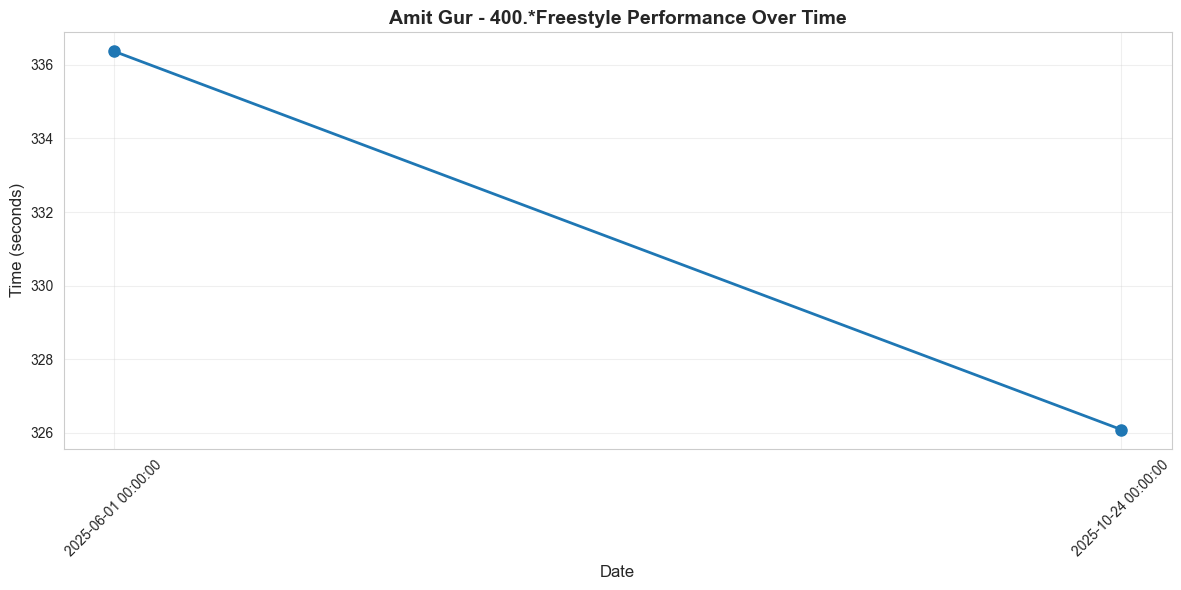

In [20]:
# Use modular function for individual performance analysis
amit_400m_free = individual_performance_analysis(df, 'Amit Gur', '400.*Freestyle')

In [ ]:
# Visualization is automatically generated by the function above

## 18. Event-Specific Analysis: 400m Freestyle All Boys Categories


400.*Freestyle Distribution Summary:
  Total results: 21
  Categories: ['Boys 15-16']

Statistics by Category:
            count    mean  median     min     max
Category                                         
Boys 15-16     21  260.85  261.94  242.24  279.94


c:\Repository\SwinLaLigScrap\notebooks\01_eda\../..\src\analysis\player_features.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=event_data, x='Category', y='result_seconds',


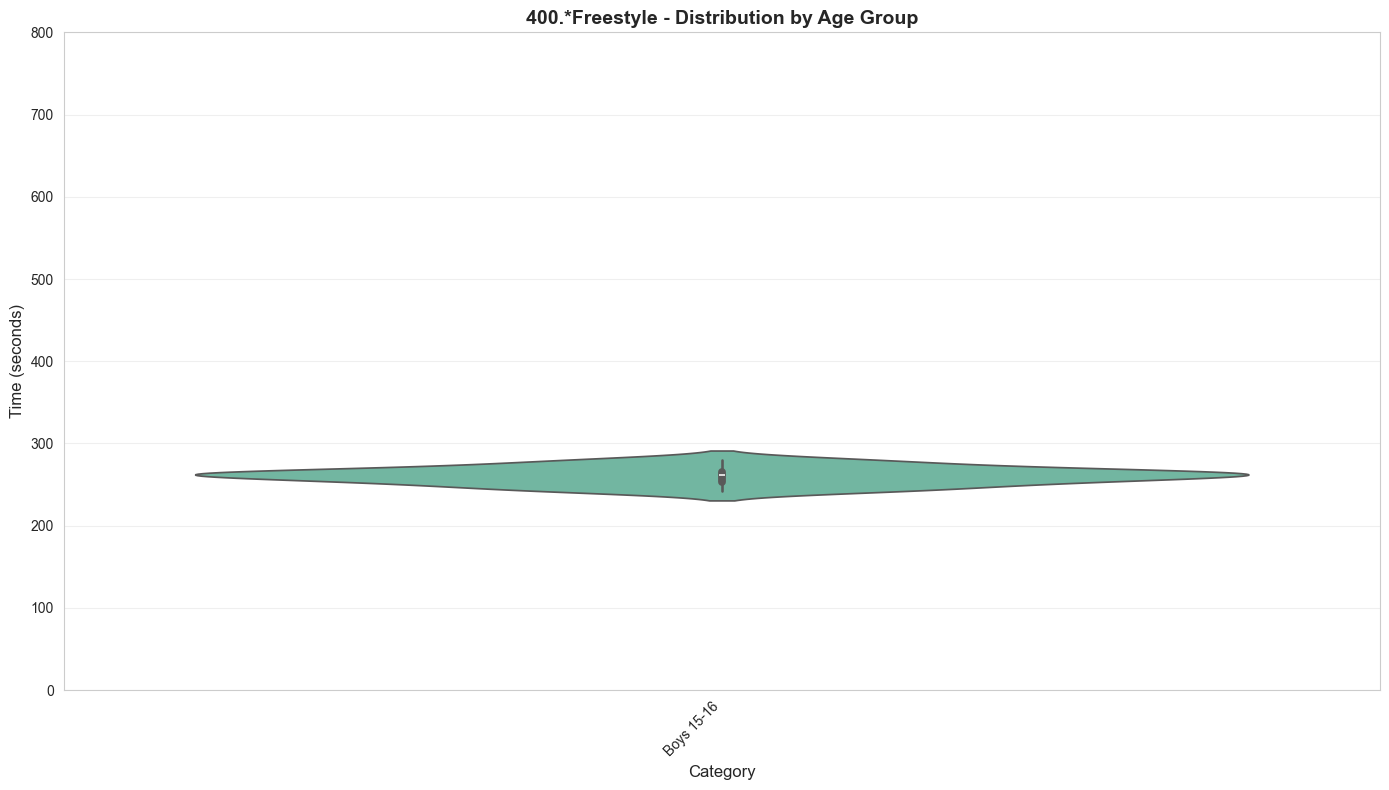

In [21]:
# Use modular function for event-specific analysis
event_400free_boys = event_specific_analysis(
    df,
    '400.*Freestyle',
    categories=['Boys 11-12', 'Boys 13-14', 'Boys 15-16', 'Boys 17-18'],
    ylim=(0, 800)
)

In [ ]:
# Visualization and statistics are automatically generated by the function above

## 19. Comparative Analysis: Amit Gur vs. Same Birth Year - 400m Freestyle

In [ ]:
# Get Amit Gur's year of birth
amit_birth_year_400freestyle = df[df['Full name'].str.lower() == 'amit gur']['Year Of Birth'].iloc[0]
print(f"Amit Gur's Year of Birth: {amit_birth_year_400freestyle}")

# Filter for all swimmers with same birth year in 400m Freestyle - BOYS ONLY
same_birth_year_400freestyle_df = df[
    (df['Year Of Birth'] == amit_birth_year_400freestyle) &
    (df['Event'].str.contains('400.*Freestyle', case=False, na=False)) &
    (df['Category'].str.contains('Boys', case=False, na=False)) &
    (df['result_seconds'].notna())
].copy()

# Group by Full name and take only the best (minimum) time for each swimmer
same_birth_year_400freestyle_df = same_birth_year_400freestyle_df.groupby('Full name', as_index=False)['result_seconds'].min()

# Get Amit's results specifically
amit_400freestyle_results = same_birth_year_400freestyle_df[same_birth_year_400freestyle_df['Full name'].str.lower() == 'amit gur']['result_seconds']

print(f"\nTotal boys born in {amit_birth_year_400freestyle} with 400m Freestyle results: {len(same_birth_year_400freestyle_df)}")
print(f"Total best times for this birth year (Boys only): {len(same_birth_year_400freestyle_df)}")
print(f"Amit Gur has {len(amit_400freestyle_results)} result in this dataset")
print(f"\nAmit's best time: {amit_400freestyle_results.min():.2f}s")
print(f"\nBirth year cohort statistics (Boys only - best times):")
print(same_birth_year_400freestyle_df['result_seconds'].describe())

In [ ]:
# Create density plot with Amit's position highlighted
plt.figure(figsize=(14, 7))

# Plot density (KDE) of all results for same birth year (Boys only)
same_birth_year_400freestyle_df['result_seconds'].plot(kind='density', linewidth=2.5, color='skyblue', label='All boys (same birth year - best times)')

# Fill under the curve for better visualization
from scipy import stats
density = stats.gaussian_kde(same_birth_year_400freestyle_df['result_seconds'])
xs = np.linspace(0, 800, 500)
ys = density(xs)
plt.fill_between(xs, ys, alpha=0.3, color='skyblue')

# Overlay Amit's results
for result in amit_400freestyle_results:
    plt.axvline(x=result, color='red', linestyle='--', linewidth=2.5, alpha=0.8)

# Add a single label for Amit's results
plt.axvline(x=amit_400freestyle_results.iloc[0], color='red', linestyle='--', linewidth=2.5, alpha=0.8, label="Amit Gur's best time")

plt.title(f"400m Freestyle Performance Distribution - Birth Year {int(amit_birth_year_400freestyle)} (Boys Only)\nAmit Gur's Position Among Peers (Best Times)", 
          fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 800)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Calculate percentile rankings for Amit's results
print("\nAmit Gur's Performance Percentiles:")
for idx, result in enumerate(amit_400freestyle_results):
    percentile = (same_birth_year_400freestyle_df['result_seconds'] > result).sum() / len(same_birth_year_400freestyle_df) * 100
    print(f"  Best time ({result:.2f}s): {percentile:.1f}th percentile (better than {percentile:.1f}% of swimmers)")

# Show how many swimmers are faster/slower than Amit's best time
amit_best_400freestyle = amit_400freestyle_results.min()
faster_swimmers = (same_birth_year_400freestyle_df['result_seconds'] < amit_best_400freestyle).sum()
slower_swimmers = (same_birth_year_400freestyle_df['result_seconds'] > amit_best_400freestyle).sum()
print(f"\nCompared to Amit's best time ({amit_best_400freestyle:.2f}s):")
print(f"  Faster swimmers: {faster_swimmers} ({faster_swimmers/len(same_birth_year_400freestyle_df)*100:.1f}%)")
print(f"  Slower swimmers: {slower_swimmers} ({slower_swimmers/len(same_birth_year_400freestyle_df)*100:.1f}%)")

In [ ]:
# Use modular function for comparative analysis
cohort_ayala_100back, swimmer_ayala_100back = comparative_analysis(
    df, 
    'Ayala Saloma', 
    '100.*Backstroke', 
    'Girls',
    xlim=(60, 120)
)

In [ ]:
# Visualization and statistics are automatically generated by the function above